In [4]:
# %load_ext autoreload
# %autoreload 2

In [5]:
import numpy as np;
from k_means_methods import *;
from tensorflow.keras.datasets import mnist

## K means clustering

MNIST bestaat uit plaatjes van cijfers (0 t/m 9).
Elk plaatje is een lijst van 784 pixelwaardes.
Om data te comprimeren willen we K means clustering toepassen om prototypes te maken.

### Opdracht 1

Wat stelt één prototype voor?



Waarom is dit geheugenbesparend?

Schrijf een functie **load_mnist** die:

- De MNIST-data laadt

- De pixelwaarden (eventueel) schaalt naar 0–1


In [6]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [7]:
train_images = [normalize_and_vectorize_image(img) for img in train_images]
test_images = [normalize_and_vectorize_image(img) for img in test_images]

In [55]:
import math;
from random import choices;
import numpy as np;
import matplotlib.pyplot as plt;


def order_by_number(dataset_images, dataset_labels):
    """
    Seperate the mnist dataset into a dictionary ordered by label
    """
    ordered_images = {0: [], 1: [], 2:[], 3:[], 4:[], 5:[], 6:[], 7:[], 8:[], 9:[]}
    for i, _ in enumerate(dataset_images):
        ordered_images[dataset_labels[i]].append(dataset_images[i])
    return ordered_images


def normalize_and_vectorize_image(image):
    """
    Turn a image of variable dimesions (must be square) into a vector and normalize values between 0 and 1
    """
    flat = image.flatten()

    maximum = np.max(flat)
    normalised = flat / maximum

    return normalised



def dist(a: np.array, b: np.array):
    """
    calculate the distance between two points in N-dimensional space
    """
    abs_differances = np.abs(a - b)
    dist = math.sqrt(np.sum(abs_differances**2))
    return dist

def k_means_old(datapoints: tuple[tuple[int, int]], clusters: int):
    clusterOrigins: set[tuple[int, int]] = set(choices(datapoints, k=clusters))
    new_origins: set[tuple[int, int]]
    while True:

        clusters = dict()

        for point in datapoints:
            closest_cluster = min(clusterOrigins, key=lambda c : dist(c, point))
            if (closest_cluster not in clusters.keys()):
                clusters[closest_cluster] = list()

            clusters[closest_cluster].append(point)

        new_origins = set()
        for key in clusters:
            values = clusters[key]

            mean_x = sum(v[0] for v in values) / len(values)
            mean_y = sum(v[1] for v in values) / len(values)
            new_origins.add((mean_x, mean_y))

        if new_origins == clusterOrigins:
            return new_origins
        clusterOrigins = new_origins


def k_means(datapoints: tuple[np.array], clusters_amount: int) -> set[tuple]:
    """
    Find the cluster centers
    """
    clusterOrigins: np.array[np.array] = np.array(choices(datapoints, k=clusters_amount))
    new_origins: np.array[np.array]
    while True:

        clusters = dict()

        # reassign points to cluster_origins
        for point in datapoints:
            closest_cluster = min(clusterOrigins, key=lambda c : dist(c, point))

            closest_cluster = tuple(closest_cluster)
            if (closest_cluster not in clusters.keys()):
                clusters[closest_cluster] = list()

            clusters[closest_cluster].append(point)

        # recalcuate origins
        new_origins = list()
        for key in clusters:
            mean = np.mean(clusters[key], axis=0)
            new_origins.append(mean)

        # base case
        if np.array_equal(np.array(new_origins), clusterOrigins):
            return new_origins
        clusterOrigins = new_origins


def vector_to_image(vector: np.array):
    """
    Turn a vector into an image
    """
    length = len(vector)
    width = int(math.sqrt(length))
    square_vector = vector[:width**2]
    image = np.reshape(square_vector, (width, width))
    return image


def show_image(image):
    """
    Show a greyscale square image of any resolution. Image is stored in 2d array.
    """
    plt.imshow(image, cmap="grey")
    plt.show()


In [64]:
ordered_images = order_by_number(train_images, train_labels)
#show_image(vector_to_image(train_images[0]))

prototypes = k_means(ordered_images[3], 1)

### Stap 2: Prototypes maken

We maken per cijfer een aantal prototypes (gemiddelde plaatjes).

Schrijf een functie **make_prototype** die:

- Voor elk cijfer (0–9) de bijbehorende trainingsbeelden selecteert

- Met K-means k clusters maakt

- Alle cluster-centers opslaat als prototypes

- Per prototype het juiste cijfer onthoudt

- Alle prototypes en bijbehorende labels in een datastructuur returnt


Hint:

- Gebruik een for-loop over de cijfer waardes (0 - 9)

- maak van elk van de waardes een lijstje van de afbeeldingen die erij horen

- Gebruik KMeans uit sklearn.cluster on van dit lijstje een prototype te maken


    **km = KMeans(n_clusters=k)**
    
    vindt K groepen in de data

    **km.fit(X_digit)**

    je kunt de cluster centers ( prototypes) achterhalen met:

    **km.cluster_centers_**


Bedenk goed dat je functie terug moet geven: prototypes en labels. Denk na over welke datastructuur je hiervoor wilt gebruiken.



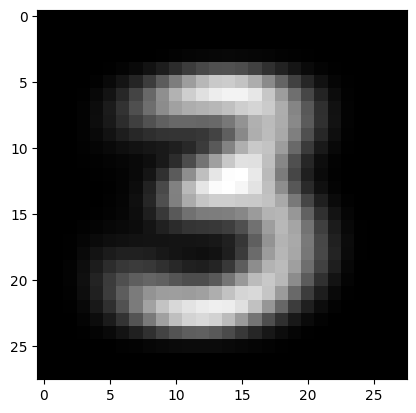

In [65]:
for key in prototypes:
    img = vector_to_image(key)
    show_image(img)

In [ ]:
for key in prototypes:
    value = prototypes[key]
    for vec in value:
        img = vector_to_image(vec)
        show_image(img)

IndexError: arrays used as indices must be of integer (or boolean) type

Maak nu een stukje code waarmee je de bovenstaande functies aanroept en een (of meer) van de prototypes laat zien.

### Stap 3 – Cijfers voorspellen

Stel we willen het cijfer voosrpellen foor te kijken naar de afstand tot een prototype. 
Een onbekend plaatje wordt dus vergeleken met alle prototypes.

Om te beginnen moeten we een functie hebben die de afstanden tussen 2 afbeeldingen (of een lijst van pixels) berekent.

Noem de functie **get_distance(image1, image2)**. deze geeft een getal terug die de som is van alle pixel verschillen.




Schrijf een functie **predict** die:

- Voor elk testplaatje de afstand tot alle prototypes berekent

- Het prototype kiest dat het meest lijkt

- Het bijbehorende cijfer - de label van de beste prototype teruggeeft

Wat betekent “afstand” hier?

Waarom gebruiken we de kleinste afstand?

Probeer nu een random afbeelding te voorspellen aan de hand van je **predict** functie.

### Stap 4 – Experimenteren

Schrijf code die:

- De data splitst in train en test

- Prototypes maakt (aan de hand van je eerder gemaakte functie)

- Voorspellingen doet (predict functie aanroept)

- De accuracy berekent

- Het geheugengebruik van de prototypes print

Hint:

- Accuracy = aantal juiste voorspellingen / totaal

        Tip: gebruik **accuracy = np.mean(y_pred == y_test)**

- Geheugen = array.nbytes

Test met:

k = 1, 3, 5, 10 of iets anders...


Wat gebeurt er met de accuracy als k groter wordt?

Wat gebeurt er met het geheugen?

Probeer een optimale setting te vinden en bereid hier een presentatie over. 